# 05 · Testing the DAF-MIT AIA dataset (Zenodo 12723700)

Record 12723700 adds flights beyond the challenge set (4271804): **Flt1006** (the dedicated calibration flight), **Flt1007** (navigation), and 2021 flights (Flt20xx, XYZ21 format). This notebook downloads a few of them and validates that they load, and then navigates one of them.

In [1]:
import os, sys
while not os.path.isdir('magnavlab') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, os.getcwd())
print('repo:', os.getcwd())

repo: /home/wpalka/magnav


## Download flights unique to 12723700

In [2]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from magnavlab import data, viz
from magnavlab.io import load_flight, load_map, segment_indices
data.fetch_flight('Flt1006')   # calibration flight
data.fetch_flight('Flt1007')   # navigation flight
data.fetch_flight('Flt2005')   # 2021 flight (XYZ21 format)
data.fetch_maps(['Eastern_395'])

  Flt1006: already present, skip
  Flt1007: already present, skip
  Flt2005: already present, skip
  maps: already present, skip


['data/maps/Eastern_395.h5']

## Structural validation — do all flights load with the required fields?
Covers both the 2020 (XYZ20) and 2021 (XYZ21) formats.

In [3]:
required = ['tt','lat','lon','alt','mag_1_c','mag_4_uc','igrf','diurnal']
for name in ['Flt1006','Flt1007','Flt2005']:
    flight = load_flight(f'data/{name}_train.h5')
    missing = [k for k in required if not flight.has(k)]
    try:
        flight.flux(); has_flux = True
    except Exception:
        has_flux = False
    print(f"{name}: {flight.n:7d} samples @ {1/flight.dt:.0f} Hz, ~{flight.n*flight.dt/60:.0f} min, "
          f"flux={has_flux}, missing={missing or 'none'}")

Flt1006:  108318 samples @ 10 Hz, ~181 min, flux=True, missing=none
Flt1007:  114506 samples @ 10 Hz, ~191 min, flux=True, missing=none
Flt2005:    6361 samples @ 10 Hz, ~11 min, flux=True, missing=none


## Flt1006 — the dedicated calibration flight
`data.CAL_SEGMENTS['Flt1006']` holds the pitch/roll/yaw maneuver windows used to fit the Tolles-Lawson coefficients. The attitude excursions are what make the aircraft-field terms observable.

9 calibration segments, 40986 samples total


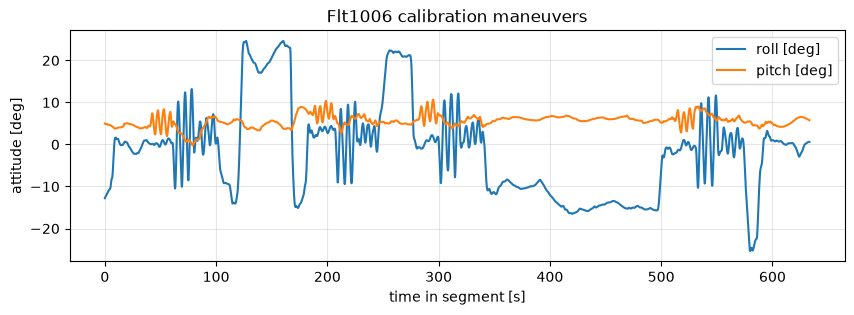

In [4]:
cal_flight = load_flight('data/Flt1006_train.h5')
segments = data.CAL_SEGMENTS['Flt1006']
total = sum(segment_indices(cal_flight, a, b).size for a, b in segments)
print(f'{len(segments)} calibration segments, {total} samples total')
a, b = segments[1]; maneuver = segment_indices(cal_flight, a, b)
time_s = cal_flight.get('tt')[maneuver] - cal_flight.get('tt')[maneuver][0]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_s, cal_flight.get('roll')[maneuver], label='roll [deg]')
ax.plot(time_s, cal_flight.get('pitch')[maneuver], label='pitch [deg]')
ax.set_xlabel('time in segment [s]'); ax.set_ylabel('attitude [deg]')
ax.set_title('Flt1006 calibration maneuvers'); ax.legend(); ax.grid(alpha=0.3);

## Navigability — measured field vs map, and the effect of altitude
A usable measurement correlates with the anomaly map. The Eastern_395 map is at 395 m, so flying near that altitude matches best. We compare an altitude-matched line (Flt1006 1006.08, ~400 m) with a higher one (Flt1007 1007.02, ~800 m).

Flt1006 Flt1006_1006.08: alt~432 m, corr(meas,map)=0.991
Flt1007 Flt1007_1007.02: alt~833 m, corr(meas,map)=0.954


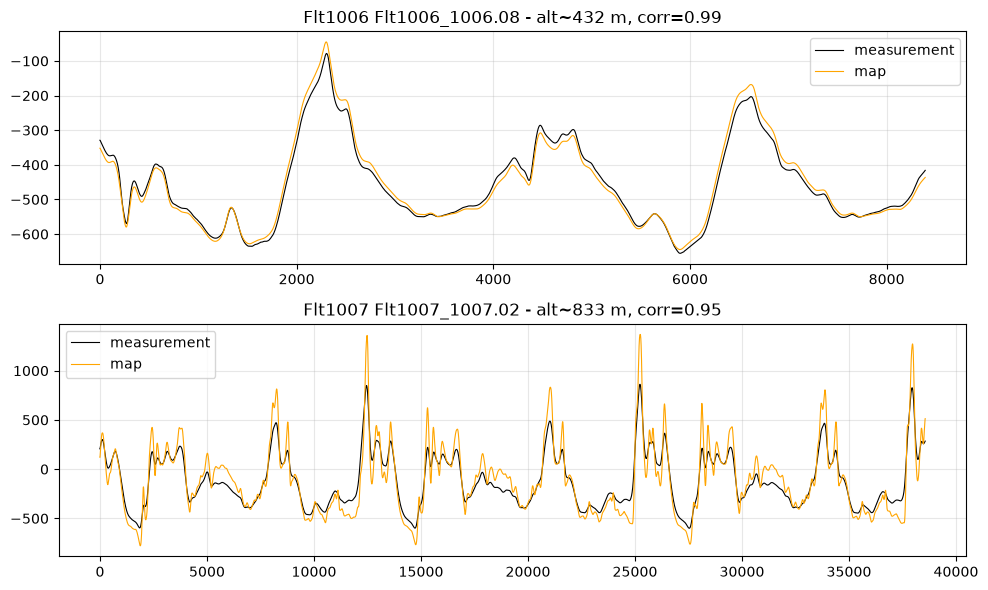

In [5]:
mag_map = load_map('data/maps/Eastern_395.h5')
def profile(name, tstart, tend):
    flight = load_flight(f'data/{name}_train.h5')
    idx = segment_indices(flight, tstart, tend)
    lat = np.radians(flight.get('lat')[idx]); lon = np.radians(flight.get('lon')[idx])
    scalar = flight.get('mag_1_c')[idx] - flight.get('diurnal')[idx]
    map_along = mag_map.value(lat, lon); valid = np.isfinite(map_along)
    scalar = scalar - np.median(scalar[valid] - map_along[valid])
    corr = np.corrcoef(scalar[valid], map_along[valid])[0, 1]
    return scalar, map_along, flight.get('alt')[idx].mean(), corr

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
for row, (name, key) in enumerate([('Flt1006','Flt1006_1006.08'), ('Flt1007','Flt1007_1007.02')]):
    window = data.NAV_WINDOWS[key]
    scalar, map_along, mean_alt, corr = profile(name, window['tstart'], window['tend'])
    print(f"{name} {key}: alt~{mean_alt:.0f} m, corr(meas,map)={corr:.3f}")
    ax[row].plot(scalar, 'k-', lw=0.8, label='measurement')
    ax[row].plot(map_along, color='orange', lw=0.8, label='map')
    ax[row].set_title(f'{name} {key} - alt~{mean_alt:.0f} m, corr={corr:.2f}')
    ax[row].legend(); ax[row].grid(alpha=0.3)
fig.tight_layout();

Higher-altitude lines correlate less with the low-altitude map (the crustal field looks low-pass filtered with altitude) — the expected physics, and a reminder to match flight and map altitude (or upward-continue the map).

## Navigation on the new dataset — tightly-coupled EKF38, position vs truth
Line 1007.06 of **Flt1007** (unique to record 12723700) is a long, altitude-matched survey over `Renfrew_395`. We run the full 38-state filter (loosely- vs tightly-coupled) as in notebook 04 and overlay the estimate on the map. This fetches the Renfrew map (~710 MB, one-off).

  maps: already present, skip


INS       DRMS=  2653.4 m
loosely   DRMS=   133.0 m
tightly   DRMS=    66.6 m


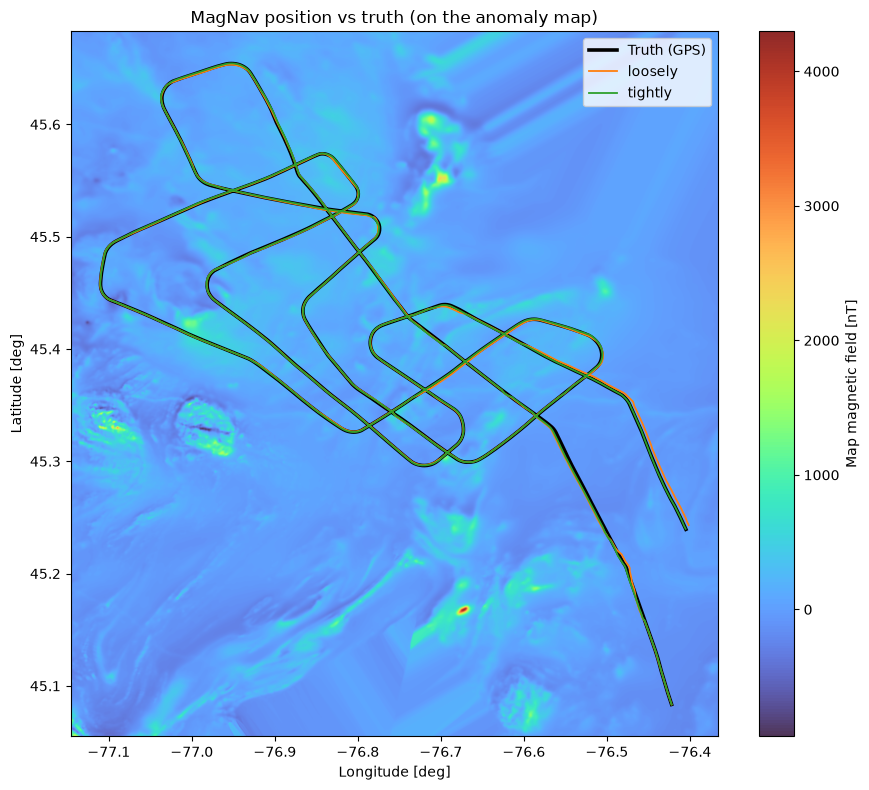

In [6]:
from magnavlab.ins import build_kinematics, simulate_ins_pinson
from magnavlab.calibration import MapBasedModifiedTL
from magnavlab.filters import Canciani38EKF
from magnavlab.interfaces import NavProblem, NavResult
from magnavlab.metrics import summary

data.fetch_maps(['Renfrew_395'])                       # matched-altitude map for 1007.06
renfrew_map = load_map('data/maps/Renfrew_395.h5')
window = data.NAV_WINDOWS['Flt1007_1007.06']
flight = load_flight('data/Flt1007_train.h5')
idx = segment_indices(flight, window['tstart'], window['tend'])[::5]; dt = flight.dt * 5; n = idx.size
lat = np.radians(flight.get('lat')[idx]); lon = np.radians(flight.get('lon')[idx])
alt = flight.get('alt')[idx]
kinematics = build_kinematics(lat, lon, alt, dt,
                              np.radians(flight.get('roll')[idx]), np.radians(flight.get('pitch')[idx]))
flux = flight.flux(idx); scalar = flight.get('mag_4_uc')[idx].astype(float)
core = flight.get('mag_1_c')[idx] - flight.get('igrf')[idx] - flight.get('diurnal')[idx]
cos_x, cos_y, cos_z = flux.x/scalar, flux.y/scalar, flux.z/scalar
cos_dot = (np.gradient(cos_x, dt), np.gradient(cos_y, dt), np.gradient(cos_z, dt))
ins, _ = simulate_ins_pinson(lat, lon, alt, kinematics, dt)
half = n // 2; earth_field = renfrew_map.value(lat[:half], lon[:half]) + core[:half]
tl_batch = MapBasedModifiedTL().fit(flight.flux(idx[:half]), scalar[:half], dt, target=earth_field)
problem = NavProblem(dt=dt, map=renfrew_map, lat=ins['lat'], lon=ins['lon'], alt=ins['alt'],
                     vN=ins['vN'], vE=ins['vE'], vD=ins['vD'], meas=scalar, core=core,
                     flux=flux, cos_dot=cos_dot, fn=kinematics['fn'], fe=kinematics['fe'],
                     fd=kinematics['fd'], Cnb=kinematics['Cnb'], tl0=tl_batch.coef, P_tl0=tl_batch.P_cov)
loose = Canciani38EKF(mode='loosely').run(problem)
tight = Canciani38EKF(mode='tightly').run(problem)
for name, result in [('INS', NavResult(ins['lat'], ins['lon'])), ('loosely', loose), ('tightly', tight)]:
    print(f"{name:9s} DRMS={summary(result, lat, lon)['drms']:8.1f} m")
viz.plot_tracks_vs_truth(renfrew_map, lat, lon, {'loosely': (loose,'tab:orange'), 'tightly': (tight,'tab:green')});

Record 12723700 is fully supported (2020 and 2021 flights); its Flt1007 navigates with the same tightly-coupled filter used in notebook 04.